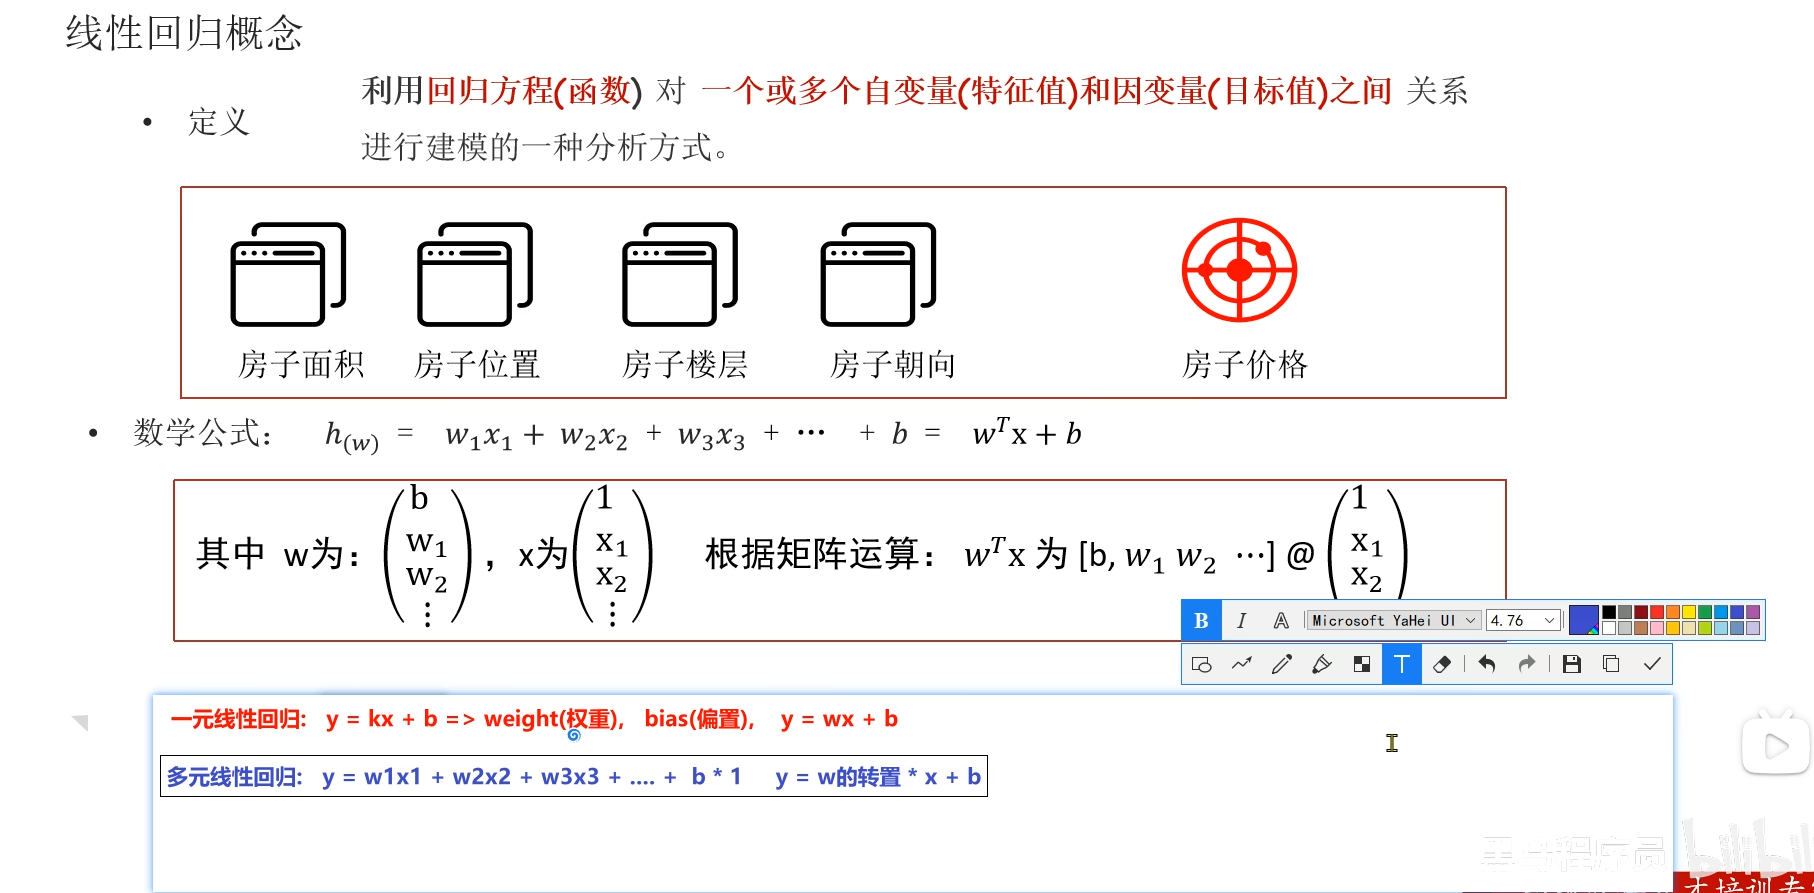

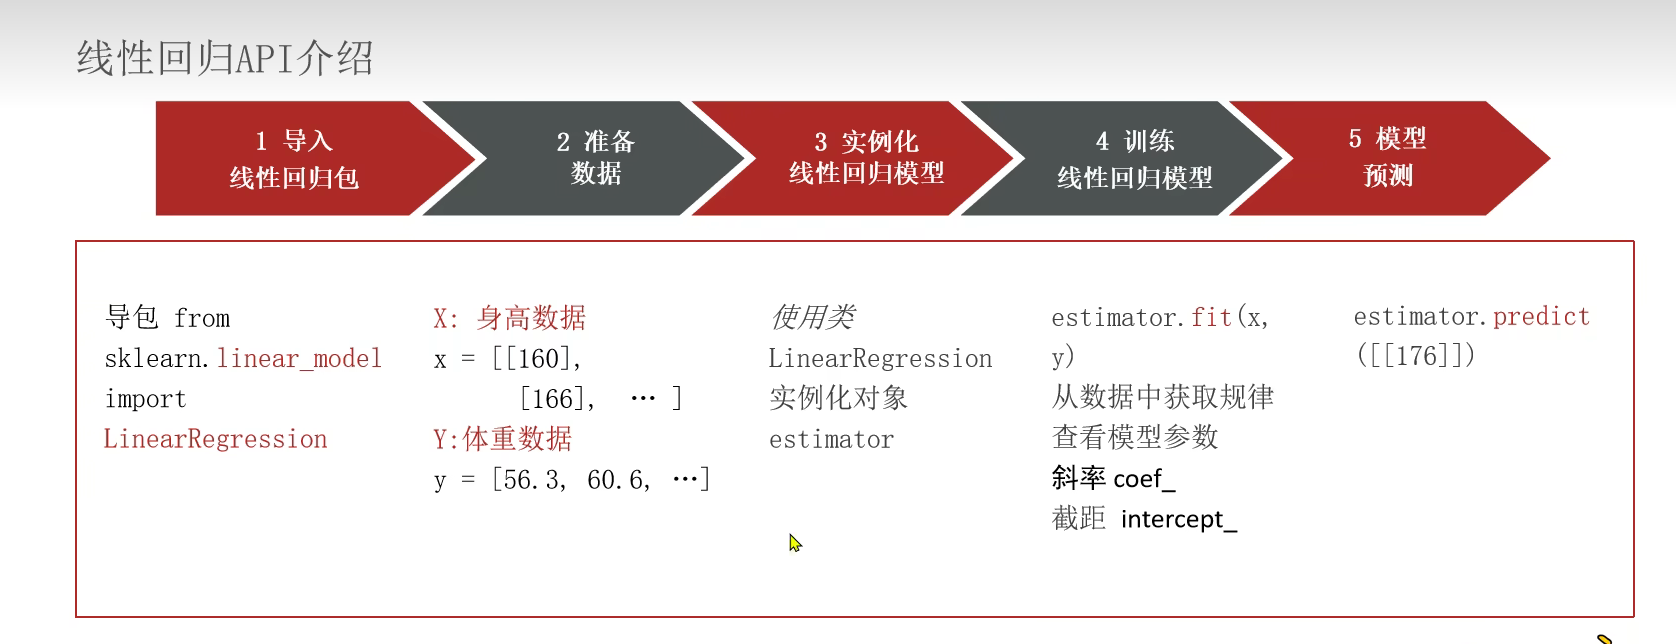

In [ ]:
#导包
from sklearn.linear_model import LinearRegression

In [ ]:
#线性回归API入门

#1.加载数据
x_train=[[160],[166],[172],[174],[180]]
y_train=[56,60,65,68,75]
x_test=[[176]]

#2. 数据预处理（不需要）
#3. 特征工程（特征提取、特征预处理） 不需要

#4. 模型训练
#4.1 创建模型对象
estimator=LinearRegression()
#4.2 具体的训练动作
estimator.fit(x_train,y_train)
#4.3 因为是线性回归模型 我们可以看一下斜率(w:权重)，截距（b:编置）
print(estimator.coef_) #权重
print(estimator.intercept_)#偏置

#5. 模型预测
y_pred=estimator.predict(x_test)
print(y_pred)

#6.模型评估

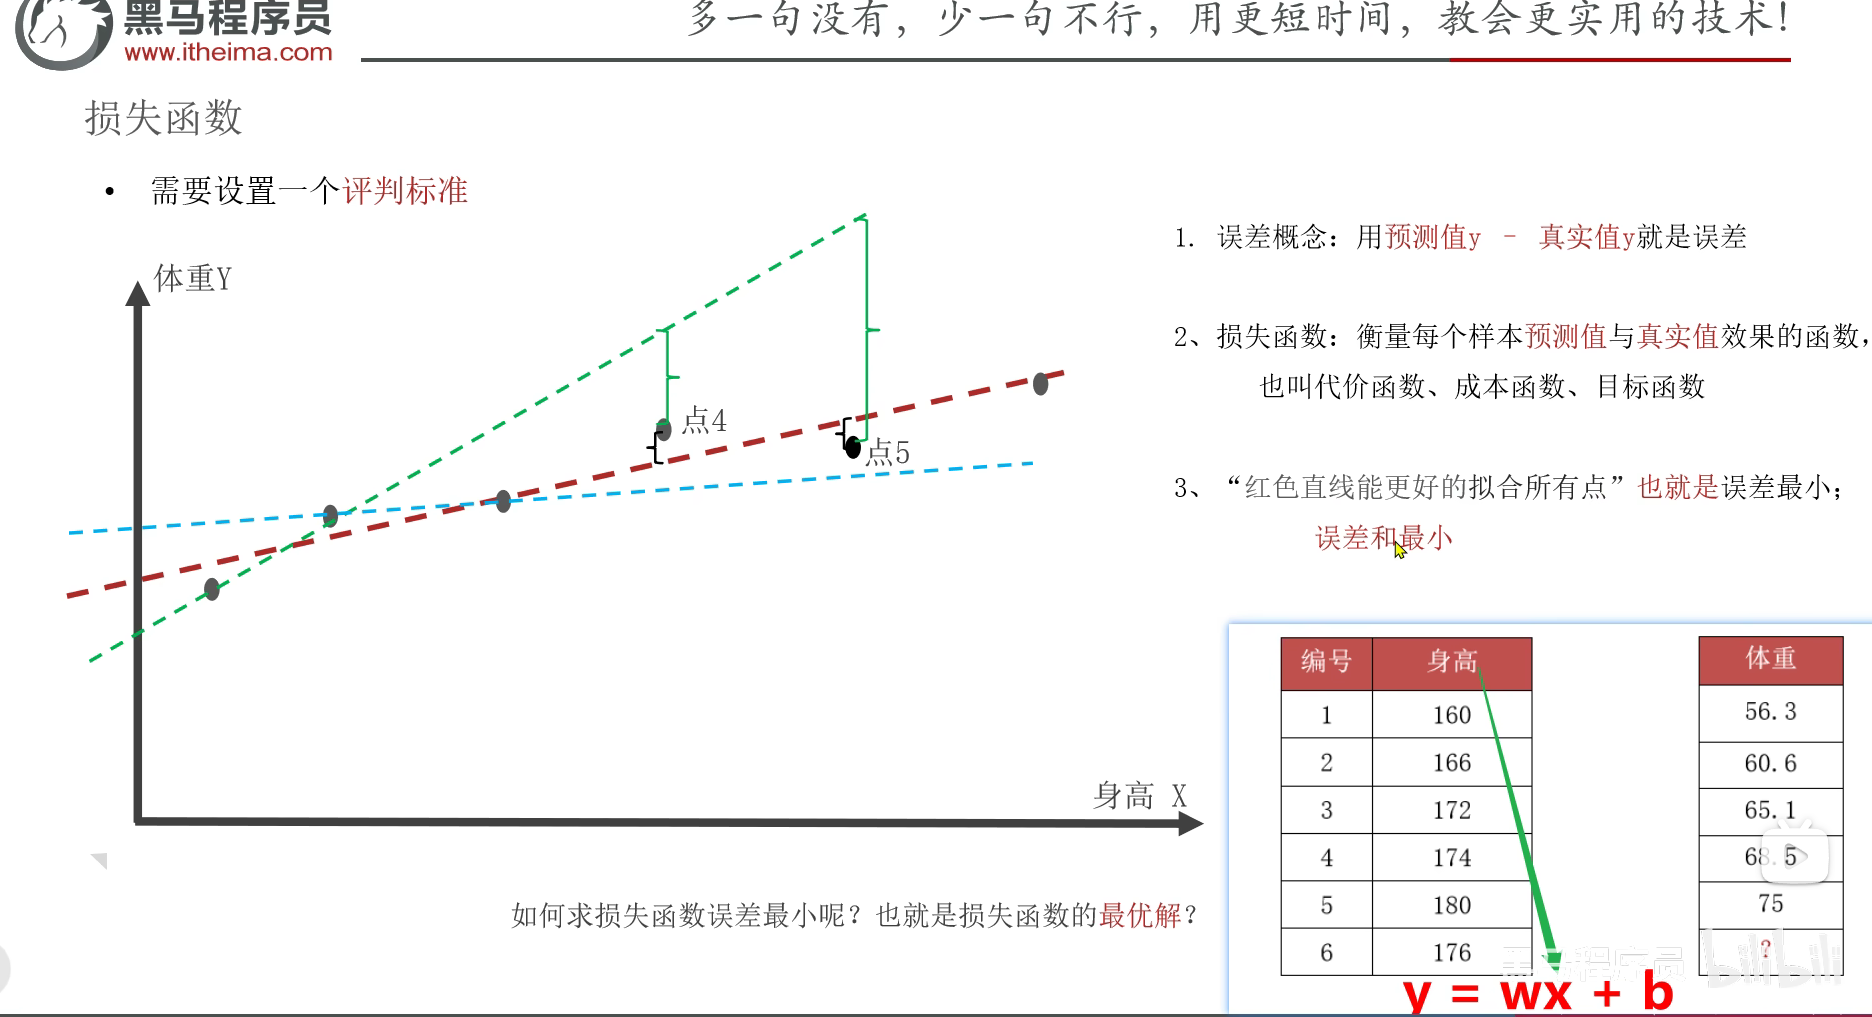

损失函数越小 误差值越小 线性回归效率、评估越高
让损失函数最小化的两种方法：正规方程 梯度下降

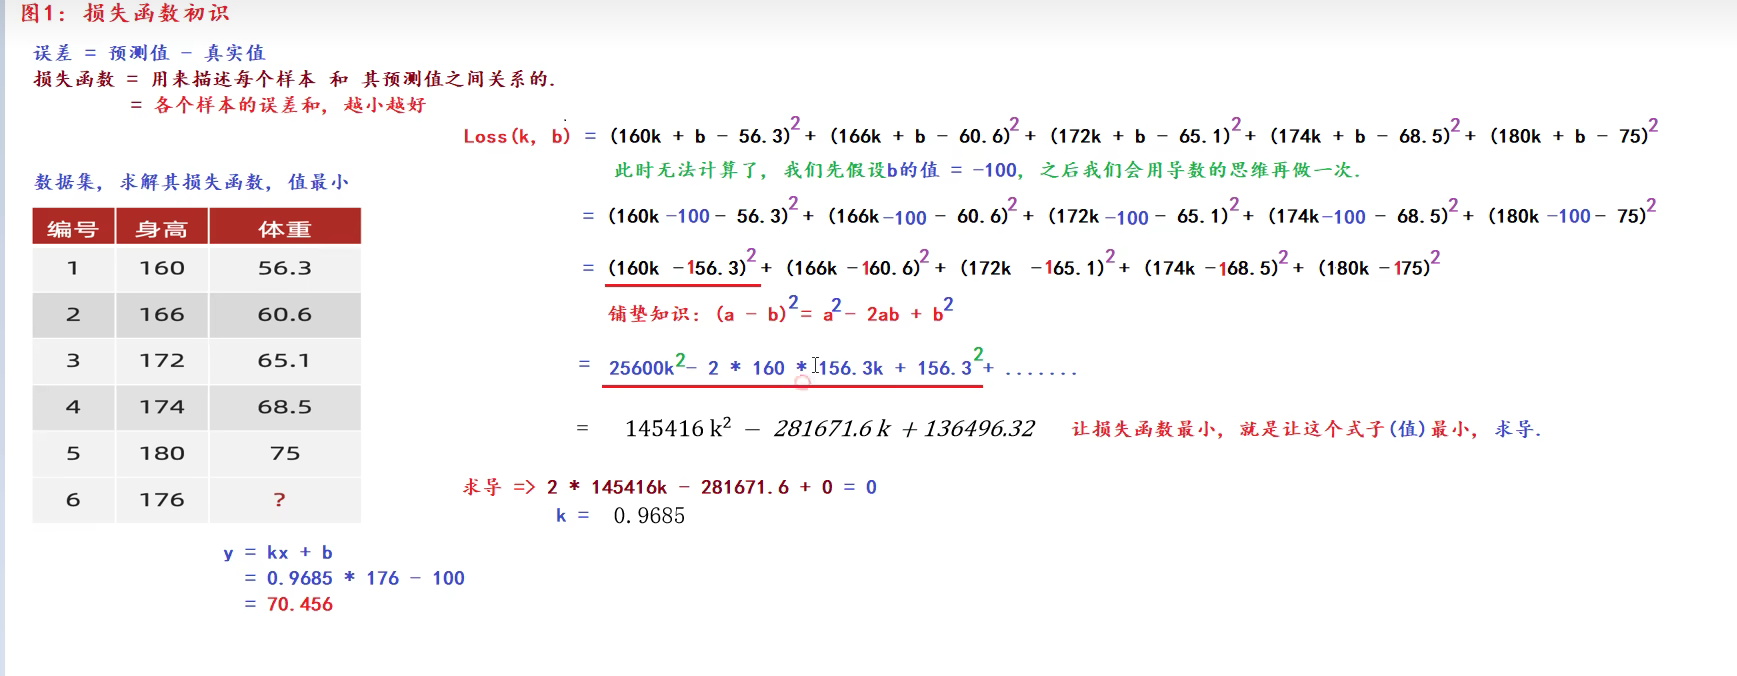

* 例题中的方法是最小二乘
* 损失函数：就是权重与偏置作为未知数的函数 同样也是预测值与真实值的差值
* 差值越小，也就是损失函数越小，说明预测值与真实值差距越小 该预测结果就越准确
* 让损失函数小对于此例题来说就是 求导数=0的点 该点为最小
* 图片上将b设为-100 一个未知数仅需求一个导数即可简化运算过程 如过w和b都为未知数 需要高阶求导求偏导数


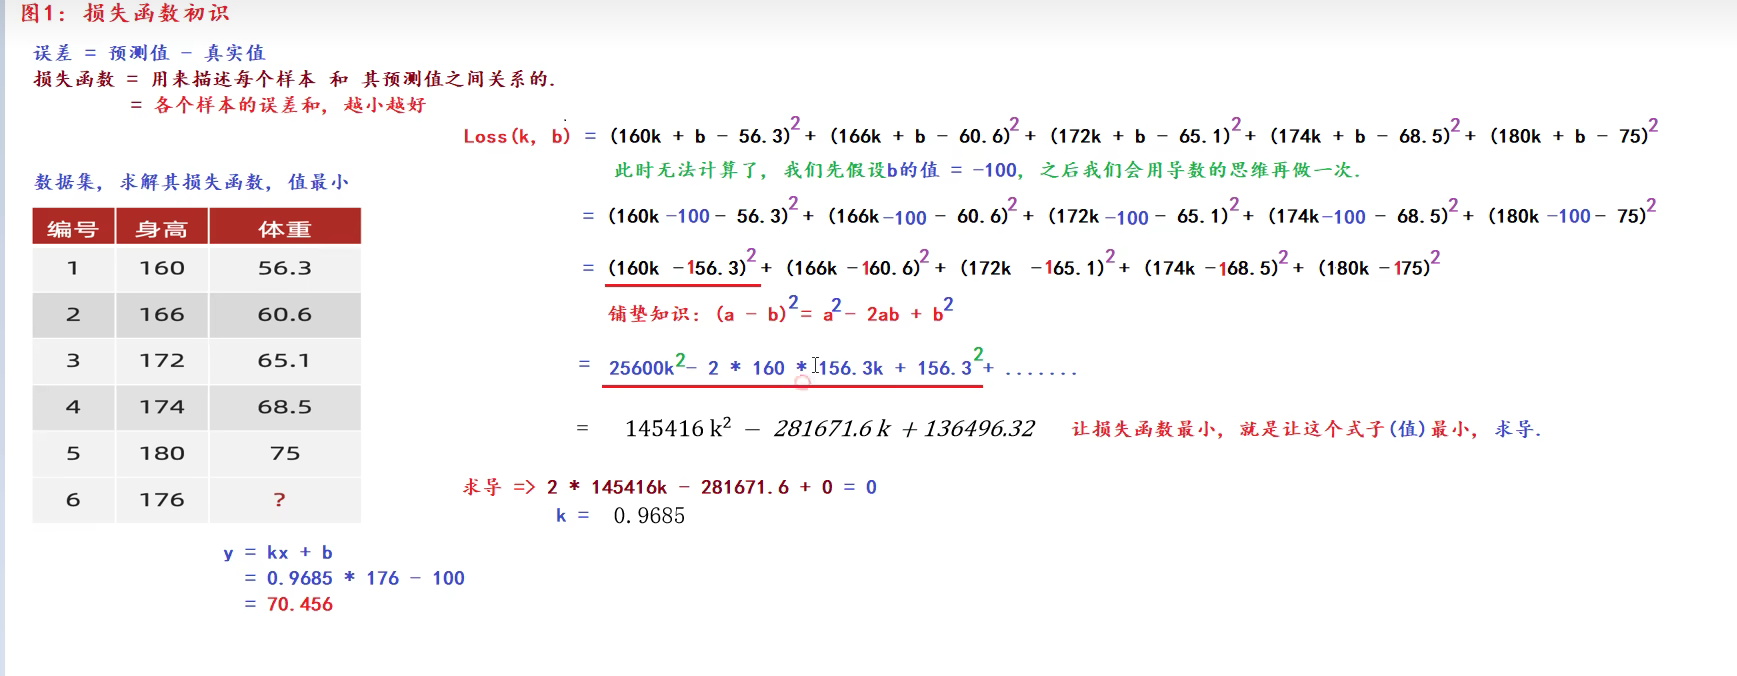

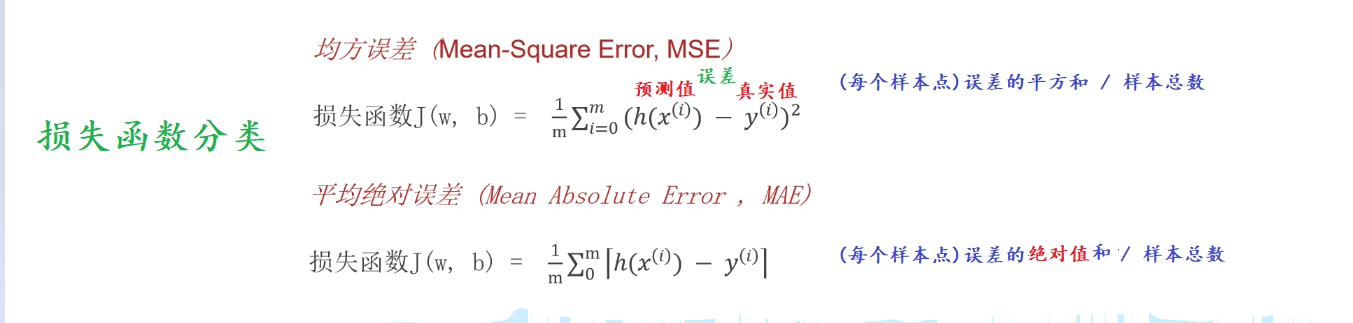

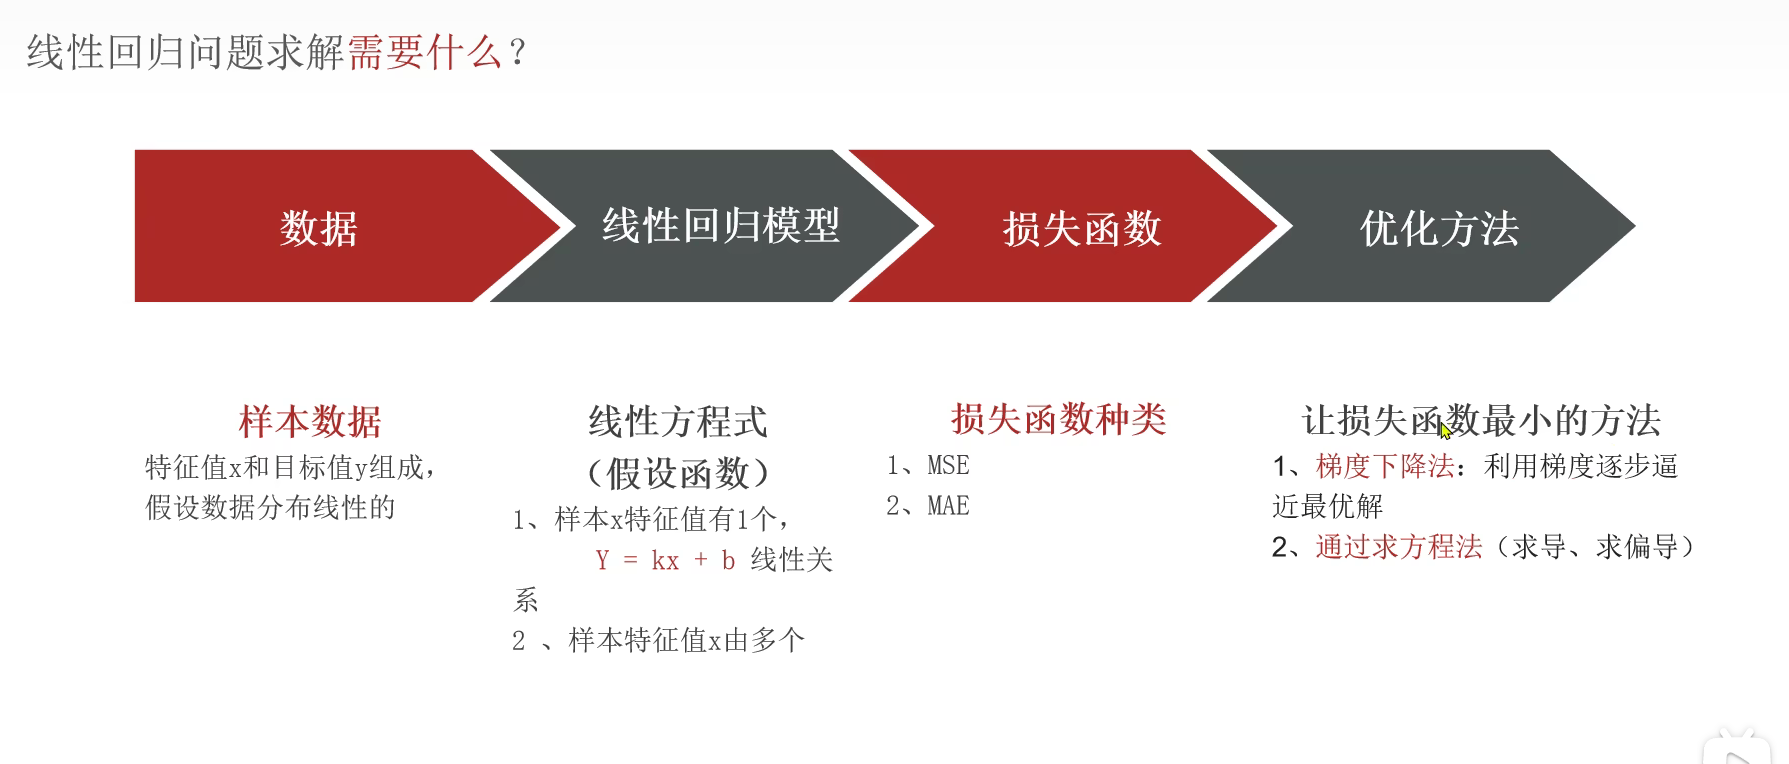

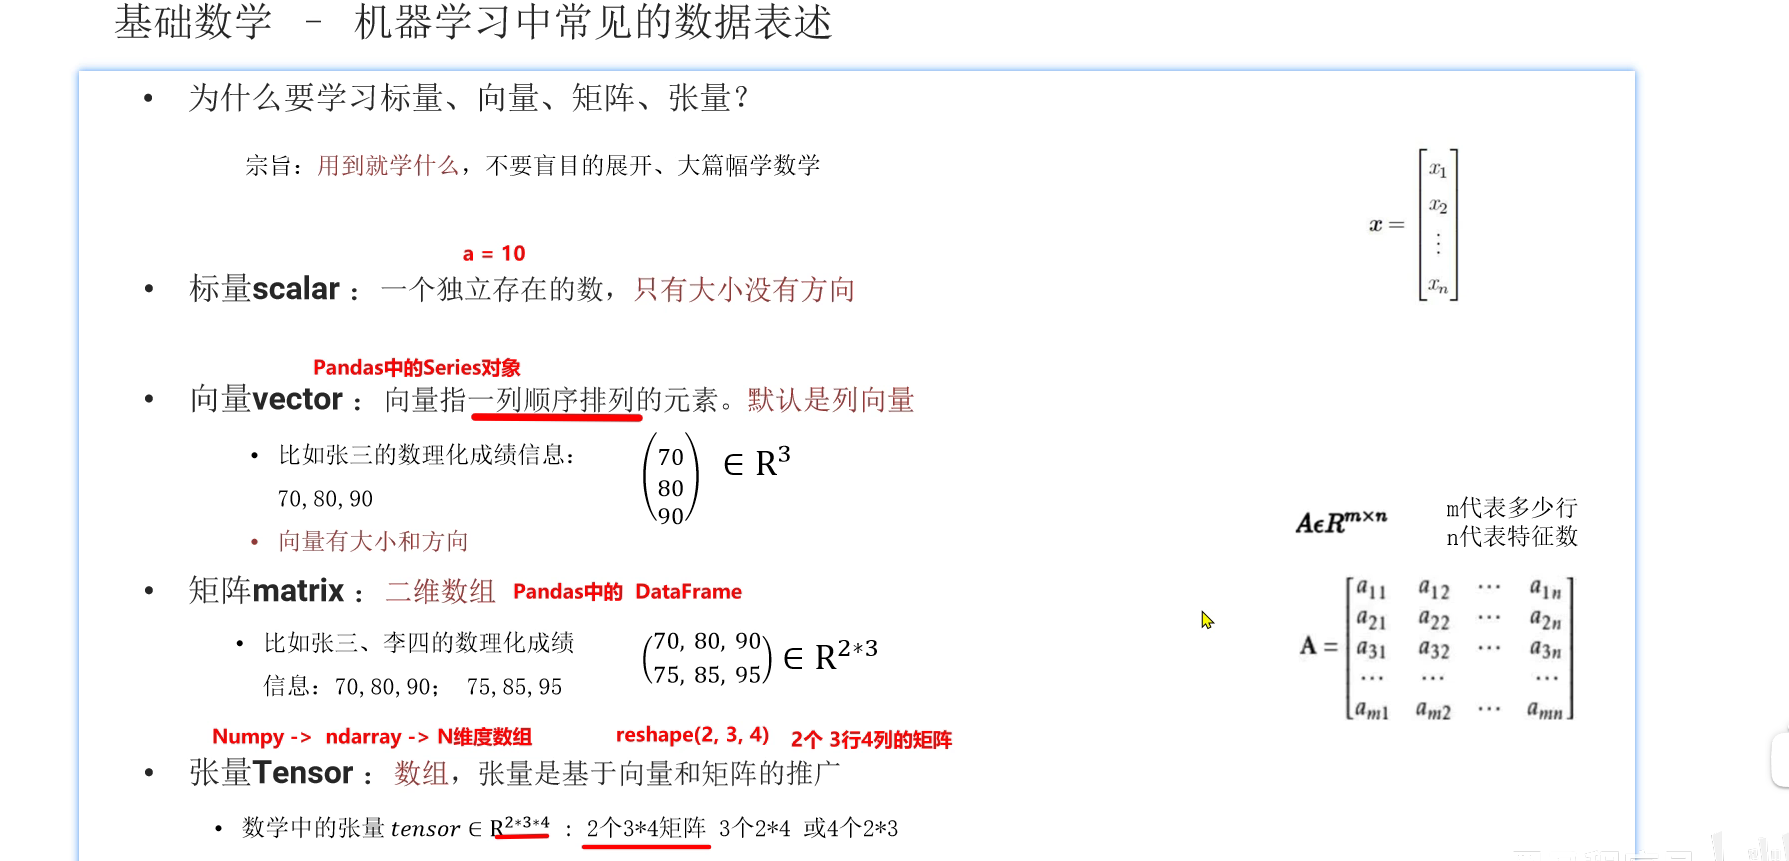

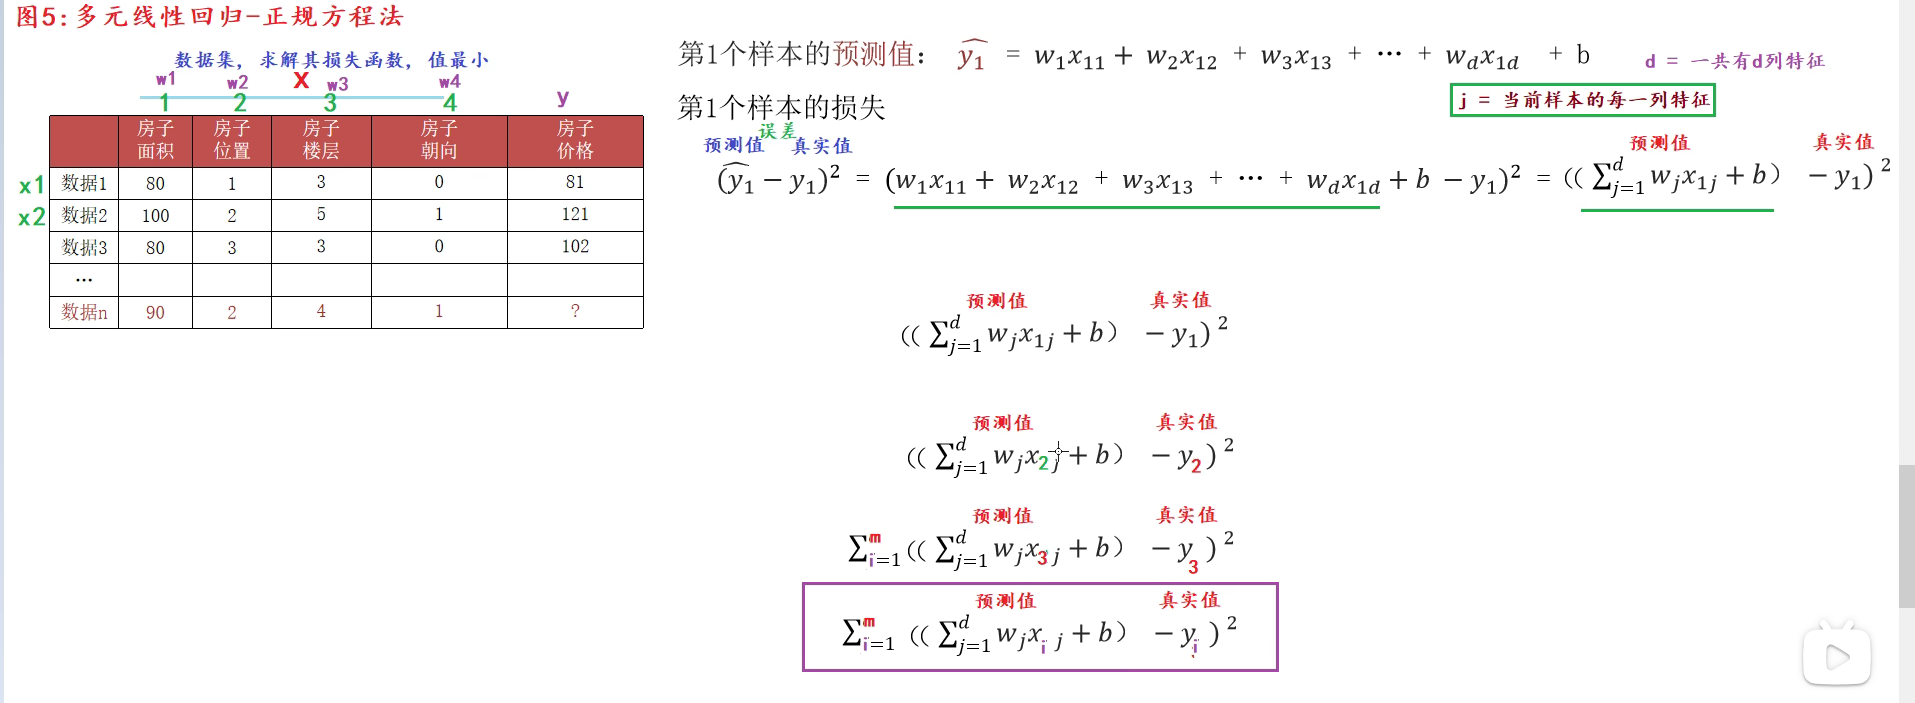

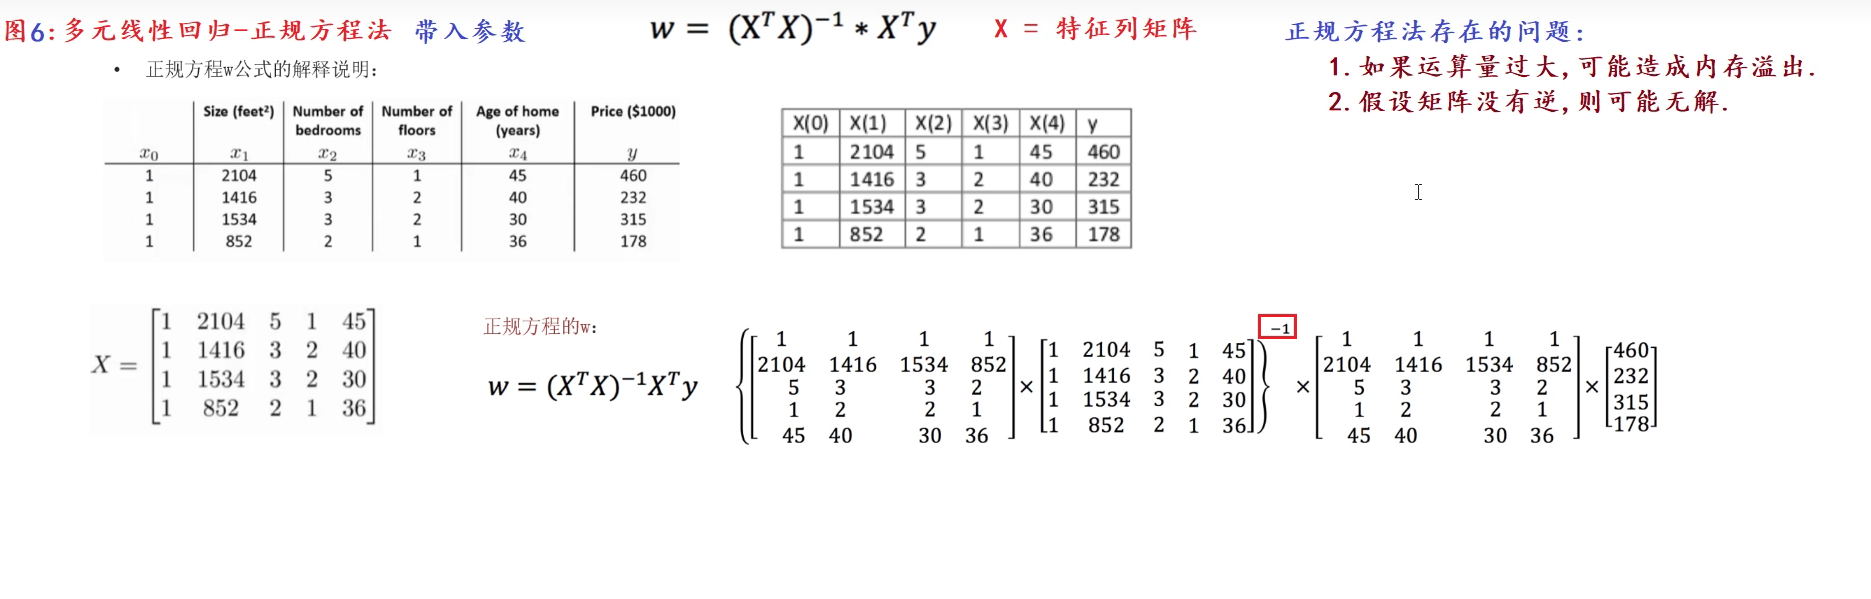

正规方程法缺点：
* 如果运算量过大 可能造成内存溢出（电脑算力不够）
* 必须可逆

# 梯度下降

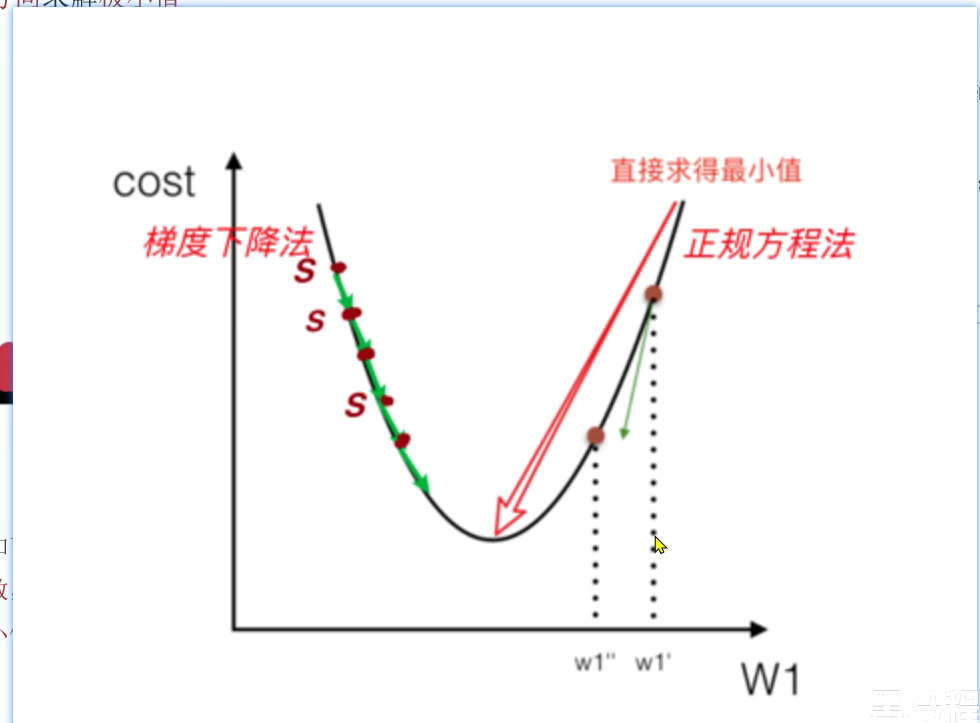

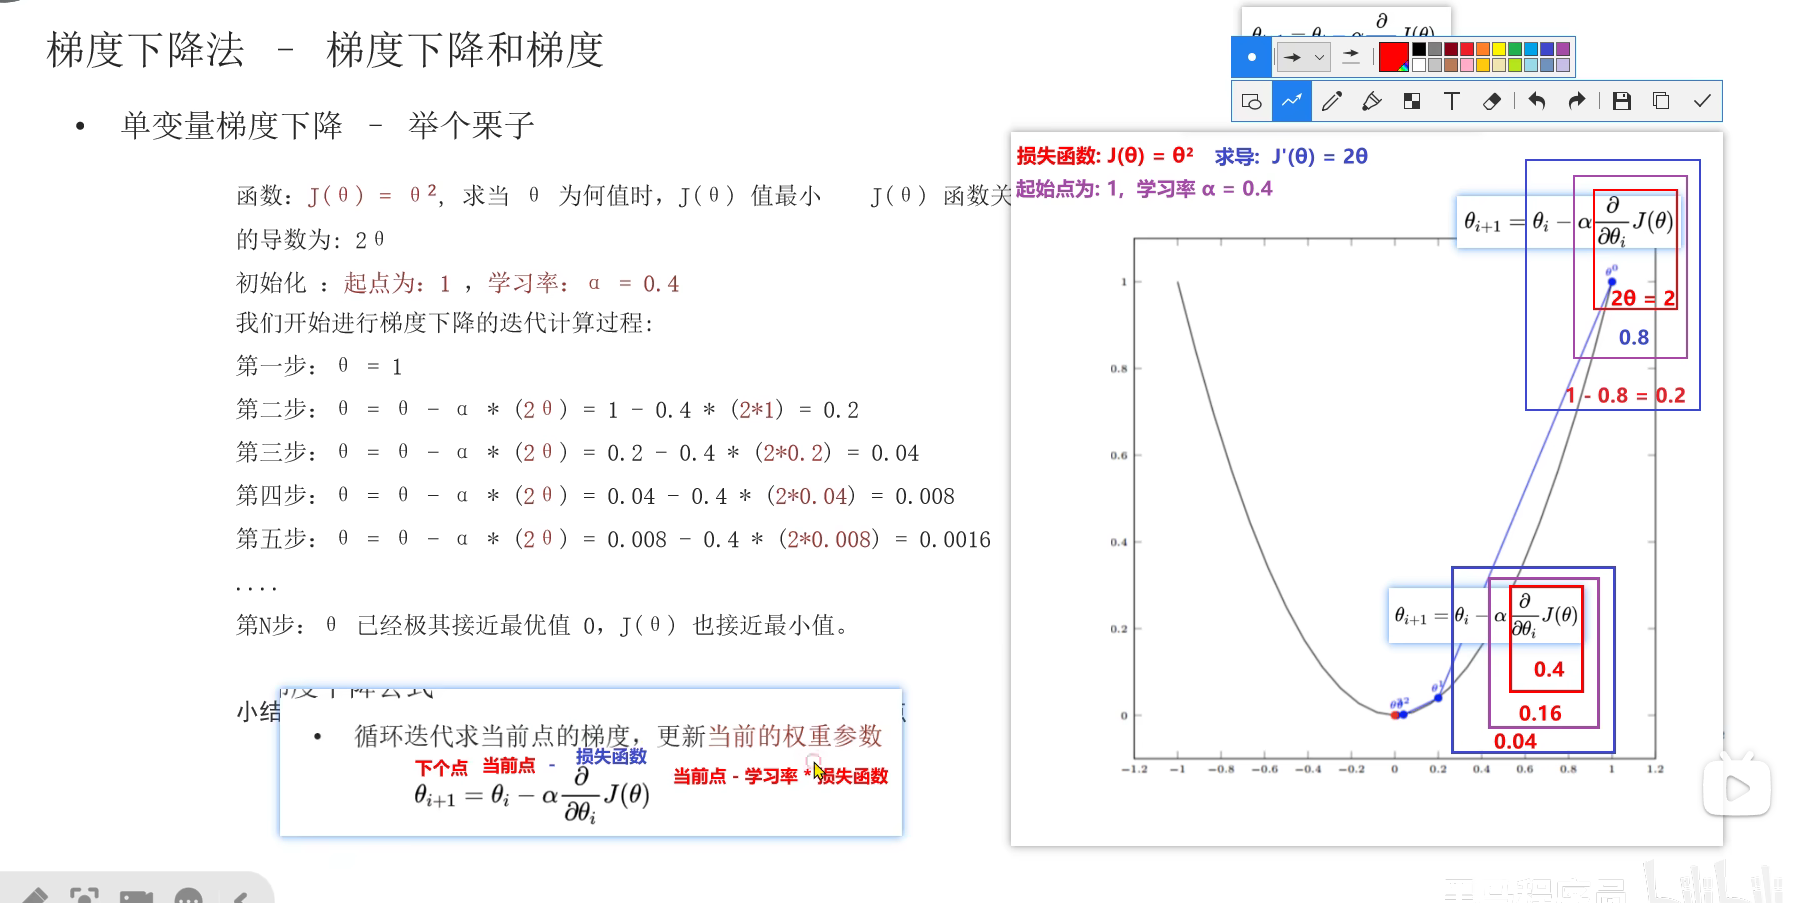

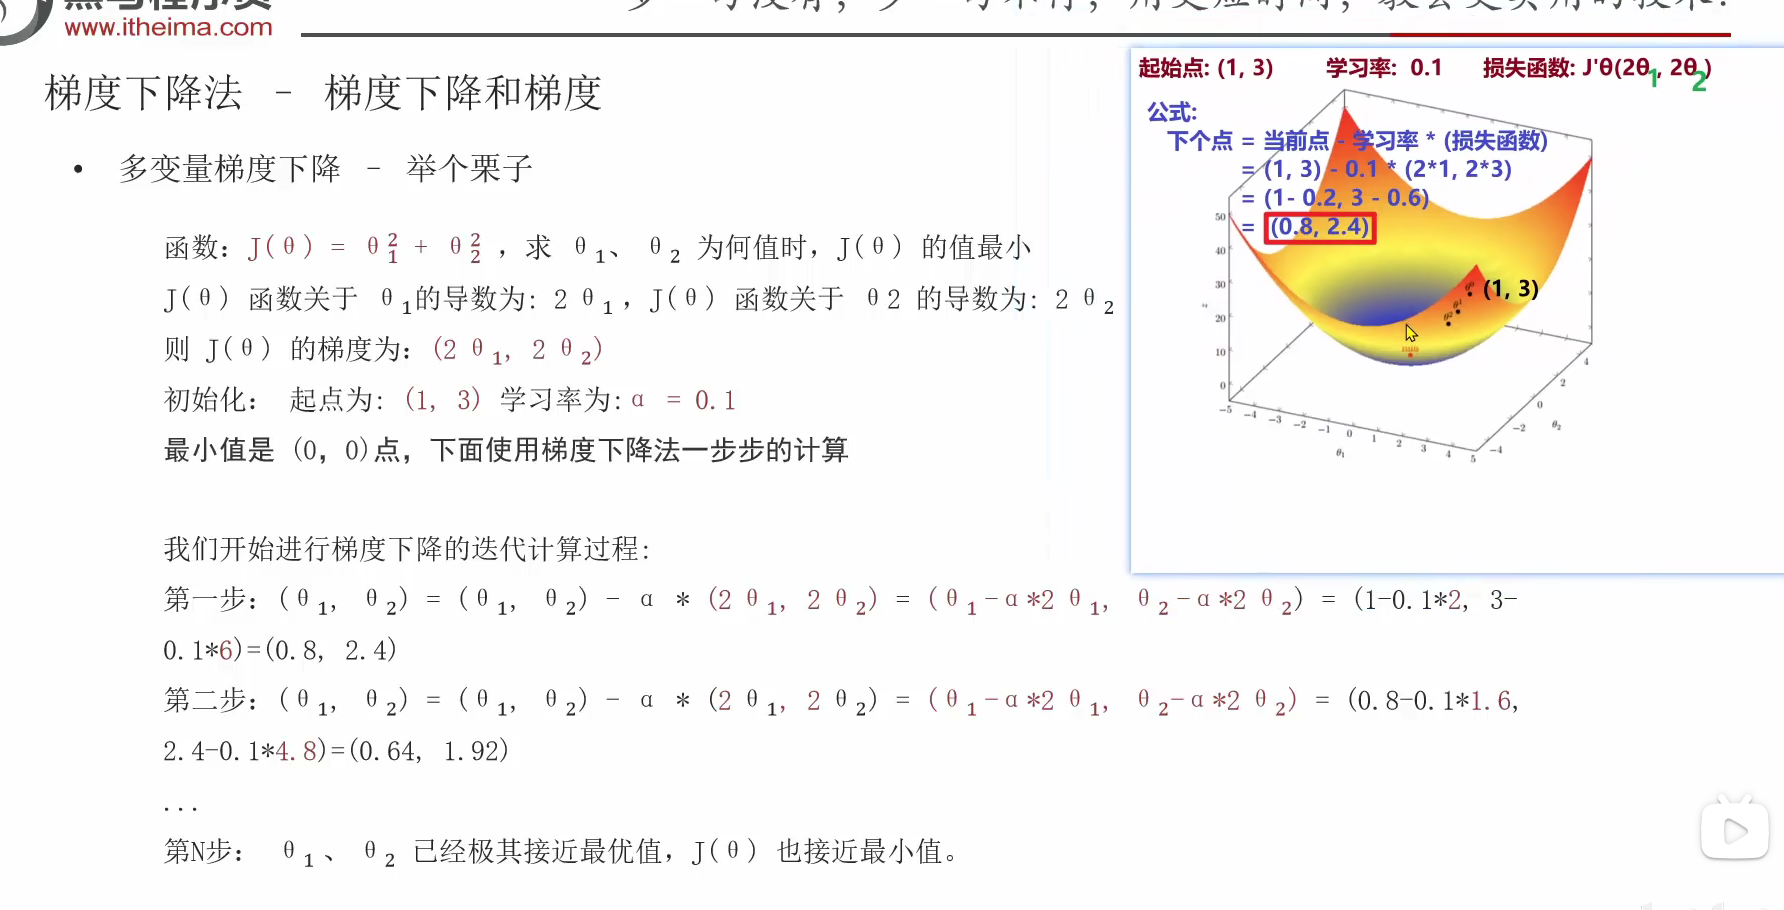

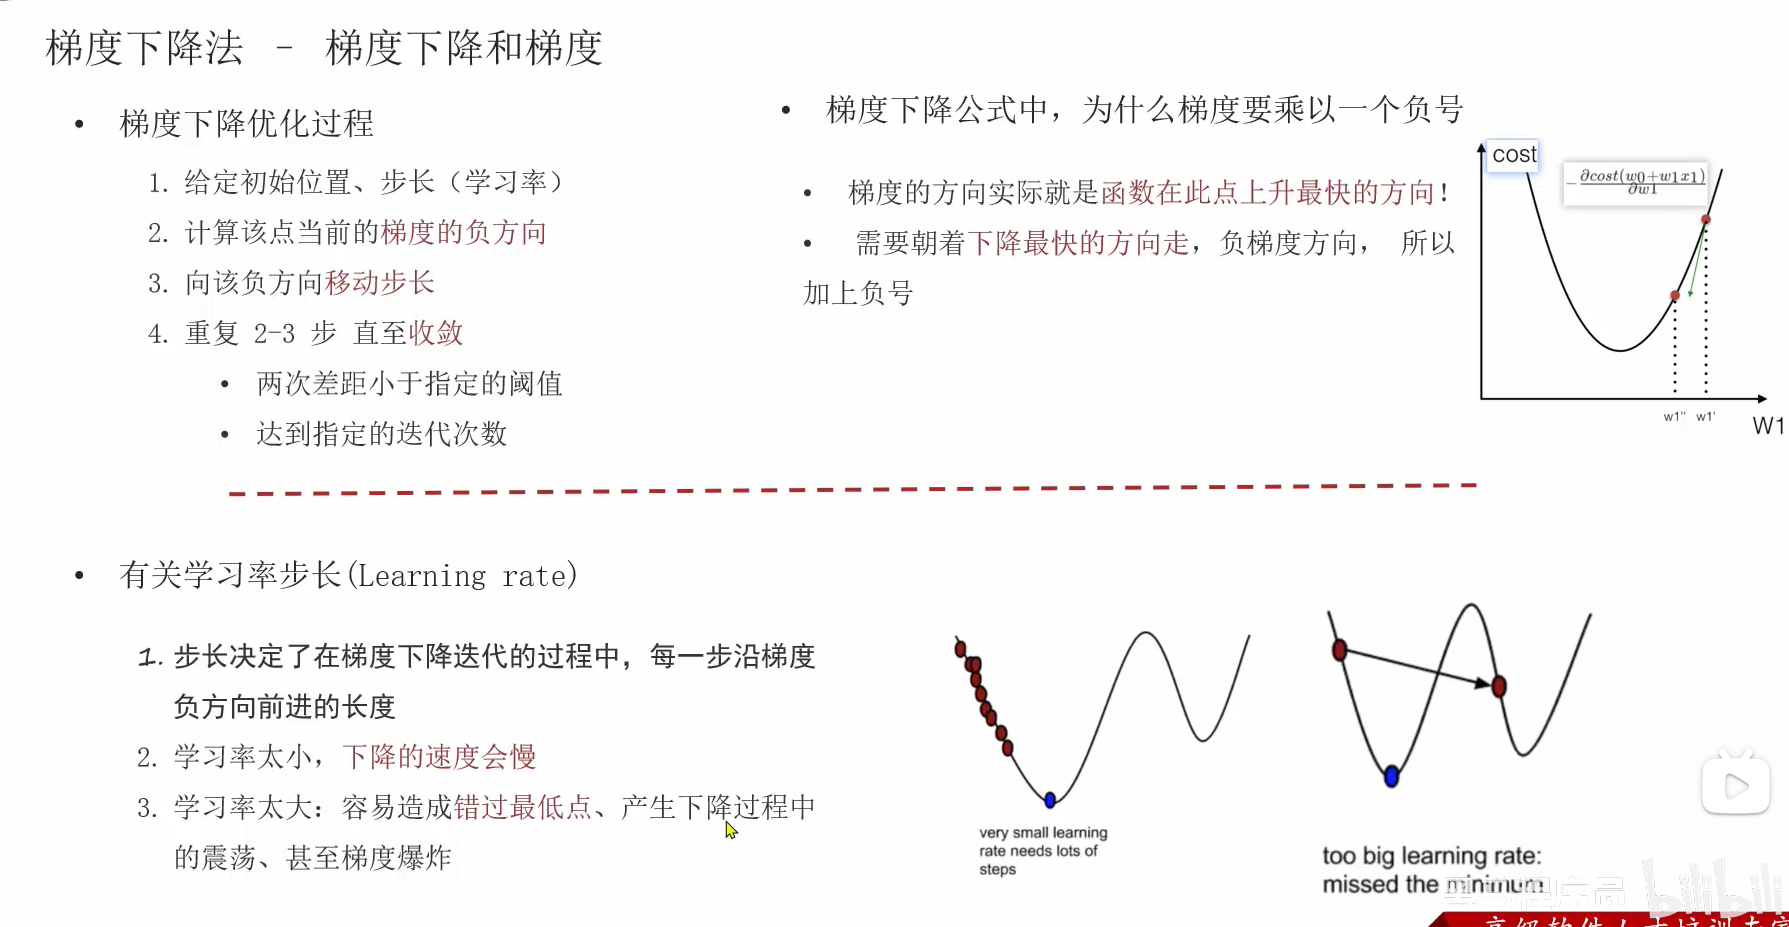

# 💡 彻底搞懂：梯度下降法 vs 正规方程法

在机器学习中，我们的终极目标是找到一组最优的参数 $w$，使得模型的**预测误差（损失函数 $J(w)$）达到最小**。为了求出这个 $w$，主要有两种方法：**正规方程法**和**梯度下降法**。

---

## 一、 核心概念大白话拆解

### 1. 什么是损失函数 $J(w)$ ？
* **核心理解**：**“模型错得有多离谱”的总分数**（误差/成本）。
* **符号含义**：$J$ 代表误差代号，$(w)$ 意味着这个误差的大小完全由你选的参数 $w$ 决定。
* **终极目标**：通过调整 $w$，让 $J(w)$ 尽可能接近 0（即误差最小，预测最准）。

### 2. 什么是偏导数（梯度） $\frac{\partial J(w)}{\partial w}$ ？
* **核心理解**：**“因果关系比例尺”** 或者是 **“鞋底感受到的坡度”**。
* **公式拆解**：
  $$\frac{\partial J(w)}{\partial w} = \frac{\text{结果：总误差 } J(w) \text{ 的变化}}{\text{原因：参数 } w \text{ 往右动了一点点}}$$
* **实际作用**：它是计算机的“方向盘”，用来探测把 $w$ 变大时，误差到底是会暴涨（正数）还是会下降（负数），从而决定接下来往哪调。

---

## 二、 梯度下降法（Gradient Descent）—— 摸黑下山

### 1. 核心公式
$$w = w - \alpha \cdot \frac{\partial J(w)}{\partial w}$$

翻译成人类语言：
$$\text{新参数} = \text{旧参数} - \text{步伐大小}(\alpha) \times \text{当前的坡度}$$

### 2. 公式细节机制
* **为什么是减号（`-`）？—— 自动方向修正**
  * **在右边斜坡**：坡度为正，减去一个正数，$w$ 会变小（向左走）。
  * **在左边斜坡**：坡度为负，减去一个负数变成加法（$-\times- = +$），$w$ 会变大（向右走）。
  * **结论**：无论参数初始在哪里，减号都能自动把你拉向谷底。
* **学习率 $\alpha$ 是什么？—— 步伐放大器**
  * 控制每一步迈多远。太大容易飞过谷底（无法收敛）；太小像蜗牛爬（训练太慢）。
* **为什么能自动停下？**
  * 离谷底越近，坡度 $\frac{\partial J(w)}{\partial w}$ 越接近 0，步子就会自动变小。当走到谷底平地时，坡度为 0，公式变成 $w = w - 0$，参数不再更新，达到最优解。



---

## 三、 两种方法的终极对比

除了梯度下降，线性回归还可以用一种基于线性代数“一步到位”的方法，叫做**正规方程法**。

| 特性 | 正规方程法 (Normal Equation) | 梯度下降法 (Gradient Descent) |
| :--- | :--- | :--- |
| **核心思想** | 用纯数学方法令导数为 0，直接推导公式：<br>$w = (X^T X)^{-1} X^T y$ | 沿着梯度的反方向，一步步迭代调整 $w$。 |
| **计算方式** | **解析解**：不需要循环，丢进公式一步到位。 | **数值解**：需要写循环，成百上千次迭代。 |
| **超参数** | 不需要设置学习率 $\alpha$。 | **必须**精心调整学习率 $\alpha$。 |
| **特征规模 ($n$)**| 特征太多时（如 $n > 10,000$），矩阵求逆 $(X^T X)^{-1}$ 计算极慢（复杂度 $O(n^3)$），内存易崩溃。 | 特征极多、数据量极大时，依然能高效运行。 |
| **适用场景** | 适用于特征较少、简单的线性回归。 | 适用于海量数据、复杂模型（如深度学习、大语言模型）。 |

---

## 📌 总结口诀
> **数据量小用正规，直接公式不后悔；**
> **数据量大用梯度，老老实实迈脚步；**
> **减号自动正方向，坡度为零就收工！**

* 两次差距小于指定阈值：指定阈值为：0.004 如果两次梯度下降的点的差距为小于等于则不再梯度下降
* 达到指定迭代次数：设置总共进行几次梯度下降 达到次数就不再梯度下降
* 如果你设置的学习率比较小 推荐使用设置阈值
* 梯度下降公式：下一个点=当前点-学习率*损失函数导数的导数